In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 导入tqdm用于显示进度条
from tqdm import tqdm
import time

In [2]:
# 1. 读取数据
print("正在读取数据...")
file_path = r'C:\毕业论文\数据\rwr_results.xlsx'
df = pd.read_excel(file_path)

print("数据形状:", df.shape)
print("\n前5行数据:")
print(df.head())
print("\n列名:", df.columns.tolist())
print("\n疾病类型分布:")
print(df['Disease'].value_counts())

正在读取数据...
数据形状: (4267, 17)

前5行数据:
   Gene Disease  Site Mutation  Cluster1  SOS(SOS1)  Ras(KRAS)       BRAF  \
0  BRAF  Cancer   365    S365L  0.012149   0.007897   0.002369  -1.296403   
1  BRAF      OR   600    V600E  0.012157   0.007902   0.002371  -1.297269   
2  BRAF      OR   600    V600G  0.011920   0.007748   0.002324  -1.271975   
3  BRAF      OR   600    V600L  0.012203   0.007932   0.002380  -1.302120   
4  BRAF      OR   466    G466E -0.851101  -0.553216  -0.165965  90.817437   

       RAF1  Cluster2(MEK1/2)       ERK  Cluster3  PI3K(PIK3CA)      PTEN  \
0 -0.094019         -0.134992 -0.040498 -0.012149      0.000355  0.000005   
1 -0.094082         -0.135083 -0.040525 -0.012157      0.000355  0.000005   
2 -0.092248         -0.132449 -0.039735 -0.011920      0.000348  0.000005   
3 -0.094434         -0.135588 -0.040676 -0.012203      0.000356  0.000005   
4  6.586361          9.456679  2.837004  0.851101     -0.024845 -0.000331   

        AKT  Cluster4      IRS1  
0  0.

In [3]:
# 2. 数据预处理
print("\n" + "="*60)
print("数据预处理中...")
print("="*60)

# 分离特征和标签
X = df.iloc[:, 4:].values  # 后13列作为特征
y = df['Disease'].values   # 第二列作为标签

# 标签编码
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\n标签编码映射: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"特征形状: {X.shape}, 标签形状: {y_encoded.shape}")


数据预处理中...

标签编码映射: {'Cancer': np.int64(0), 'NDD': np.int64(1), 'OR': np.int64(2)}
特征形状: (4267, 13), 标签形状: (4267,)


In [5]:
# 3. 划分训练集、验证集和测试集
print("\n" + "="*60)
print("划分训练集、验证集和测试集...")
print("="*60)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  # 0.25 * 0.8 = 0.2
)

print(f"\n训练集大小: {X_train.shape[0]}")
print(f"验证集大小: {X_val.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")


划分训练集、验证集和测试集...

训练集大小: 2559
验证集大小: 854
测试集大小: 854


In [6]:
# 4. 特征标准化
print("\n" + "="*60)
print("特征标准化...")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



特征标准化...


In [7]:
# 5. 定义XGBoost模型和评估指标
def evaluate_model(y_true, y_pred, y_pred_proba=None, set_name="Validation"):
    """评估模型性能"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"\n{set_name} Set Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    return accuracy, precision, recall, f1


In [8]:
# 6. 使用5折交叉验证训练XGBoost模型
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
fold_metrics = []

# 存储每折的训练历史
fold_histories = []

# 特征名称
feature_names = df.columns[4:].tolist()

print("\n" + "="*60)
print("开始5折交叉验证训练")
print("="*60)

# 创建自定义回调函数来显示训练进度
class XGBProgressCallback(xgb.callback.TrainingCallback):
    def __init__(self, verbose_eval=50):
        self.verbose_eval = verbose_eval
        self.epoch = 0
        self.pbar = None
        
    def before_training(self, model):
        self.pbar = tqdm(total=model.num_boosted_rounds(), desc="Training", unit="round")
        return model
    
    def after_iteration(self, model, epoch, evals_log):
        self.epoch = epoch
        if self.pbar:
            self.pbar.update(1)
            # 更新进度条描述，显示当前轮次
            self.pbar.set_description(f"Training epoch {epoch+1}")
        
        # 每verbose_eval轮显示一次详细日志
        if self.verbose_eval and epoch % self.verbose_eval == 0 and evals_log:
            # 获取最新的训练和验证损失
            train_loss = evals_log['validation_0']['mlogloss'][-1] if 'validation_0' in evals_log else None
            val_loss = evals_log['validation_1']['mlogloss'][-1] if 'validation_1' in evals_log else None
            
            if train_loss is not None and val_loss is not None:
                tqdm.write(f"Epoch {epoch+1}: Train loss = {train_loss:.4f}, Val loss = {val_loss:.4f}")
        
        # 返回False表示继续训练，True表示停止训练
        return False
    
    def after_training(self, model):
        if self.pbar:
            self.pbar.close()
        return model

# 使用tqdm显示5折交叉验证的进度
print("\n开始5折交叉验证:")
for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(X_temp, y_temp), 
                                                  total=5, 
                                                  desc="Cross-validation folds",
                                                  unit="fold")):
    print(f"\n{'='*40}")
    print(f"训练第 {fold+1} 折")
    print(f"{'='*40}")
    
    # 划分训练和验证数据
    X_fold_train, X_fold_val = X_temp[train_idx], X_temp[val_idx]
    y_fold_train, y_fold_val = y_temp[train_idx], y_temp[val_idx]
    
    # 标准化
    X_fold_train_scaled = scaler.fit_transform(X_fold_train)
    X_fold_val_scaled = scaler.transform(X_fold_val)
    
    # 创建XGBoost模型
    model = xgb.XGBClassifier(
        n_estimators=1000,  # 设置较大的值，使用早停
        learning_rate=0.1,
        max_depth=5,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss',
        early_stopping_rounds=50,
        verbosity=0,
        callbacks=[XGBProgressCallback(verbose_eval=50)]
    )
    
    # 训练模型，使用验证集进行早停
    eval_set = [(X_fold_train_scaled, y_fold_train), (X_fold_val_scaled, y_fold_val)]
    
    # 使用tqdm显示训练进度
    start_time = time.time()
    model.fit(
        X_fold_train_scaled, 
        y_fold_train,
        eval_set=eval_set,
        verbose=False  # 禁用默认的verbose，使用我们的回调函数
    )
    end_time = time.time()
    
    print(f"第 {fold+1} 折训练完成，耗时: {end_time - start_time:.2f} 秒")
    print(f"最佳迭代次数: {model.best_iteration}")
    
    # 获取训练历史
    results = model.evals_result()
    fold_histories.append(results)
    
    # 在验证集上评估
    y_fold_val_pred = model.predict(X_fold_val_scaled)
    
    # 计算指标
    accuracy, precision, recall, f1 = evaluate_model(
        y_fold_val, y_fold_val_pred, 
        set_name=f"Fold {fold+1} Validation"
    )
    
    fold_metrics.append({
        'fold': fold + 1,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'best_iteration': model.best_iteration,
        'training_time': end_time - start_time
    })
    
    # 记录交叉验证分数
    cv_score = model.score(X_fold_val_scaled, y_fold_val)
    cv_scores.append(cv_score)
    print(f"Fold {fold+1} Accuracy: {cv_score:.4f}")

# 7. 打印交叉验证结果
print("\n" + "="*60)
print("5折交叉验证结果")
print("="*60)

cv_metrics_df = pd.DataFrame(fold_metrics)
print(cv_metrics_df)

print(f"\n平均交叉验证准确率: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")
print(f"平均F1分数: {cv_metrics_df['f1'].mean():.4f}")
print(f"平均训练时间: {cv_metrics_df['training_time'].mean():.2f} 秒")

# 8. 使用全部训练数据训练最终模型
print("\n" + "="*60)
print("训练最终模型")
print("="*60)

# 合并训练集和验证集
X_final_train = np.vstack([X_train_scaled, X_val_scaled])
y_final_train = np.concatenate([y_train, y_val])

# 计算最终模型的迭代次数
best_iteration_mean = np.mean(cv_metrics_df['best_iteration'])
n_estimators_final = int(best_iteration_mean * 1.2)
print(f"最终模型迭代次数: {n_estimators_final} (基于交叉验证平均最佳迭代次数: {best_iteration_mean:.1f})")

final_model = xgb.XGBClassifier(
    n_estimators=n_estimators_final,
    learning_rate=0.1,
    max_depth=5,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    verbosity=0
)

# 使用tqdm显示最终模型训练进度
print("\n训练最终模型中...")
with tqdm(total=n_estimators_final, desc="Final model training", unit="round") as pbar:
    # 自定义回调函数来更新进度条
    class FinalModelCallback(xgb.callback.TrainingCallback):
        def after_iteration(self, model, epoch, evals_log):
            pbar.update(1)
            pbar.set_description(f"Final model training epoch {epoch+1}")
            return False
    
    final_model.set_params(callbacks=[FinalModelCallback()])
    final_model.fit(X_final_train, y_final_train)

print("最终模型训练完成!")



开始5折交叉验证训练

开始5折交叉验证:


Cross-validation folds:   0%|          | 0/5 [00:00<?, ?fold/s]


训练第 1 折


                                                               
Cross-validation folds:   0%|          | 0/5 [00:00<?, ?fold/s]

Epoch 1: Train loss = 0.9229, Val loss = 0.9277


...

Epoch 51: Train loss = 0.6078, Val loss = 0.7081


                                                                       
Cross-validation folds: 100%|██████████| 5/5 [00:01<00:00,  3.16fold/s]


Epoch 101: Train loss = 0.5457, Val loss = 0.7173
第 5 折训练完成，耗时: 0.31 秒
最佳迭代次数: 55

Fold 5 Validation Set Performance:
Accuracy: 0.7302
Precision: 0.6959
Recall: 0.7302
F1-Score: 0.6891
Fold 5 Accuracy: 0.7302

5折交叉验证结果
   fold  accuracy  precision    recall        f1  best_iteration  \
0     1  0.726208   0.690830  0.726208  0.677814              71   
1     2  0.707174   0.656647  0.707174  0.656947              52   
2     3  0.705710   0.655922  0.705710  0.663199              37   
3     4  0.709677   0.681536  0.709677  0.646138              32   
4     5  0.730205   0.695935  0.730205  0.689074              55   

   training_time  
0       0.428440  
1       0.296610  
2       0.246986  
3       0.219057  
4       0.307432  

平均交叉验证准确率: 0.7158 (±0.0103)
平均F1分数: 0.6666
平均训练时间: 0.30 秒

训练最终模型
最终模型迭代次数: 59 (基于交叉验证平均最佳迭代次数: 49.4)

训练最终模型中...


Final model training epoch 59: 100%|██████████| 59/59 [00:00<00:00, 250.59round/s]

最终模型训练完成!


In [9]:
# 9. 在测试集上评估最终模型
print("\n" + "="*60)
print("在测试集上评估最终模型")
print("="*60)

# 使用tqdm显示预测进度
print("\n进行预测...")
with tqdm(total=len(X_test_scaled), desc="Predicting", unit="sample") as pbar:
    y_test_pred = []
    y_test_pred_proba = []
    
    # 分批预测以避免内存问题，同时显示进度
    batch_size = 32
    for i in range(0, len(X_test_scaled), batch_size):
        end_idx = min(i + batch_size, len(X_test_scaled))
        batch_X = X_test_scaled[i:end_idx]
        
        batch_pred = final_model.predict(batch_X)
        batch_pred_proba = final_model.predict_proba(batch_X)
        
        y_test_pred.extend(batch_pred)
        y_test_pred_proba.extend(batch_pred_proba)
        
        pbar.update(end_idx - i)
    
    y_test_pred = np.array(y_test_pred)
    y_test_pred_proba = np.array(y_test_pred_proba)

test_accuracy, test_precision, test_recall, test_f1 = evaluate_model(
    y_test, y_test_pred, y_test_pred_proba, "Test"
)



在测试集上评估最终模型

进行预测...


Predicting: 100%|██████████| 854/854 [00:00<00:00, 25851.15sample/s]


Test Set Performance:
Accuracy: 0.7014
Precision: 0.6605
Recall: 0.7014
F1-Score: 0.6521



生成可视化结果...


Text(0.5, 1.0, 'Feature Importance in XGBoost Model')

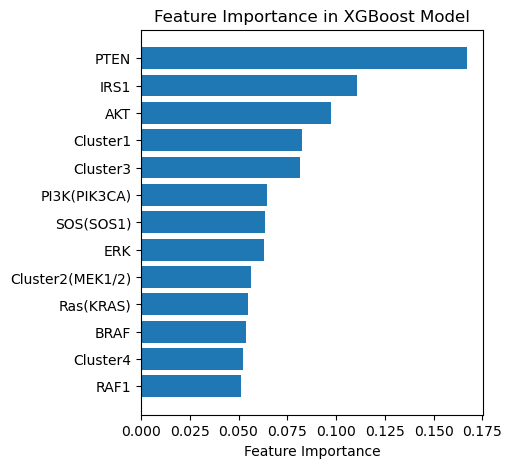

In [10]:
# 10. 可视化结果
print("\n" + "="*60)
print("生成可视化结果...")
print("="*60)

plt.figure(figsize=(15, 5))

# 子图1: 特征重要性
plt.subplot(1, 3, 1)
feature_importance = final_model.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in XGBoost Model')

Text(0.5, 23.52222222222222, 'Predicted Label')

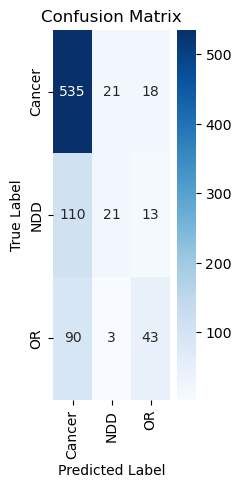

In [11]:
# 子图2: 混淆矩阵
plt.subplot(1, 3, 2)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')


正在显示图表...


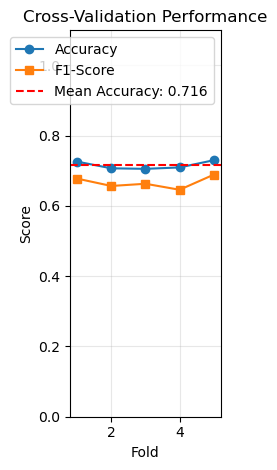

In [12]:
# 子图3: 交叉验证分数
plt.subplot(1, 3, 3)
plt.plot(range(1, 6), cv_metrics_df['accuracy'], 'o-', label='Accuracy')
plt.plot(range(1, 6), cv_metrics_df['f1'], 's-', label='F1-Score')
plt.axhline(y=np.mean(cv_metrics_df['accuracy']), color='r', linestyle='--', label=f'Mean Accuracy: {np.mean(cv_metrics_df["accuracy"]):.3f}')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Cross-Validation Performance')
plt.legend()
plt.ylim([0, 1.1])
plt.grid(True, alpha=0.3)

plt.tight_layout()
print("正在显示图表...")
plt.show()

In [13]:
# 12. 保存模型和结果
import joblib
import os

print("\n" + "="*60)
print("保存模型和结果...")
print("="*60)

# 创建保存目录
save_dir = r'C:\毕业论文\模型结果'
os.makedirs(save_dir, exist_ok=True)

# 使用tqdm显示保存进度
with tqdm(total=4, desc="Saving files", unit="file") as pbar:
    # 保存模型
    joblib.dump(final_model, os.path.join(save_dir, 'xgboost_model.pkl'))
    pbar.update(1)
    
    joblib.dump(scaler, os.path.join(save_dir, 'scaler.pkl'))
    pbar.update(1)
    
    joblib.dump(label_encoder, os.path.join(save_dir, 'label_encoder.pkl'))
    pbar.update(1)
    
    # 保存结果到CSV
    results_df = pd.DataFrame({
        'Model': ['XGBoost'],
        'CV_Mean_Accuracy': [np.mean(cv_scores)],
        'CV_Std_Accuracy': [np.std(cv_scores)],
        'Test_Accuracy': [test_accuracy],
        'Test_Precision': [test_precision],
        'Test_Recall': [test_recall],
        'Test_F1': [test_f1]
    })
    
    results_df.to_csv(os.path.join(save_dir, 'model_results.csv'), index=False)
    cv_metrics_df.to_csv(os.path.join(save_dir, 'cross_validation_details.csv'), index=False)
    pbar.update(1)

print(f"\n模型和结果已保存到: {save_dir}")
print(f"最终测试集准确率: {test_accuracy:.4f}")

# 13. 打印一些预测示例
print("\n" + "="*60)
print("预测示例")
print("="*60)

# 获取测试集的部分样本
sample_indices = np.random.choice(len(X_test), min(5, len(X_test)), replace=False)

for i, idx in enumerate(sample_indices):
    true_label = label_encoder.inverse_transform([y_test[idx]])[0]
    pred_label = label_encoder.inverse_transform([y_test_pred[idx]])[0]
    confidence = np.max(y_test_pred_proba[idx])
    
    print(f"样本 {i+1}:")
    print(f"  真实标签: {true_label}")
    print(f"  预测标签: {pred_label}")
    print(f"  置信度: {confidence:.4f}")
    print(f"  是否正确: {'✓' if true_label == pred_label else '✗'}")
    print()

print("\n" + "="*60)
print("所有任务完成!")
print("="*60)


保存模型和结果...


Saving files: 100%|██████████| 4/4 [00:00<00:00, 266.67file/s]


模型和结果已保存到: C:\毕业论文\模型结果
最终测试集准确率: 0.7014

预测示例
样本 1:
  真实标签: Cancer
  预测标签: Cancer
  置信度: 0.8167
  是否正确: ✓

样本 2:
  真实标签: Cancer
  预测标签: Cancer
  置信度: 0.8199
  是否正确: ✓

样本 3:
  真实标签: OR
  预测标签: OR
  置信度: 0.9058
  是否正确: ✓

样本 4:
  真实标签: Cancer
  预测标签: Cancer
  置信度: 0.9399
  是否正确: ✓

样本 5:
  真实标签: NDD
  预测标签: Cancer
  置信度: 0.7490
  是否正确: ✗


所有任务完成!
